In [27]:
import os
import avstack
import avapi
from matplotlib import pyplot as plt
import numpy as np
import math

%load_ext autoreload
%autoreload 2

# Importing data
data_base = '../../data'
obj_data_dir_k = os.path.join(data_base, 'KITTI/object')
raw_data_dir_k = os.path.join(data_base, 'KITTI/raw') 
data_dir_n     = os.path.join(data_base, 'nuScenes')
data_dir_c     = os.path.join(data_base, 'CARLA/ego-lidar')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# Instantiating Scene Manager
KSM = avapi.kitti.KittiScenesManager(obj_data_dir_k, raw_data_dir_k, convert_raw=False)
NSM = avapi.nuscenes.nuScenesManager(data_dir_n)
CSM = avapi.carla.CarlaScenesManager(data_dir_c)

No indices available for ../../data/KITTI/object/2011_09_26_drive_0005_sync!


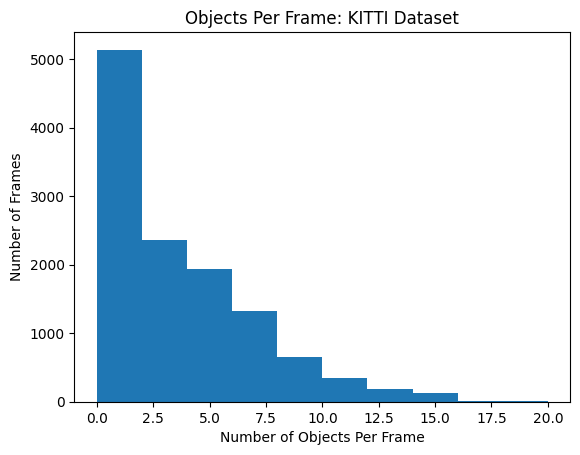

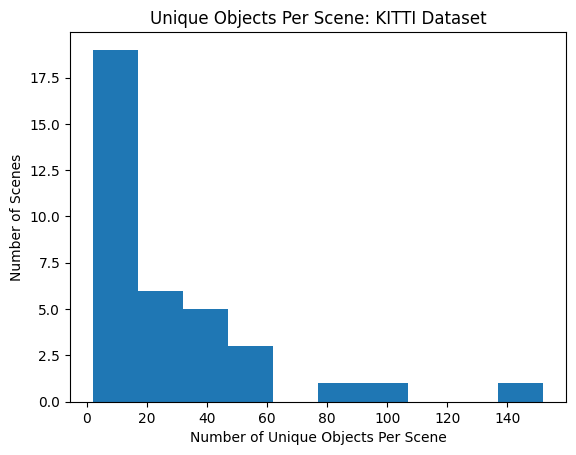

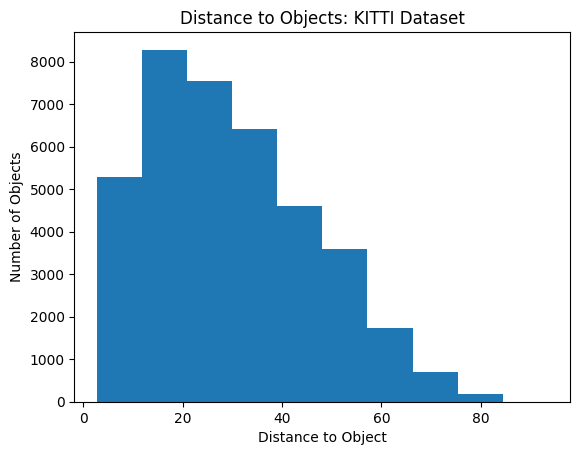

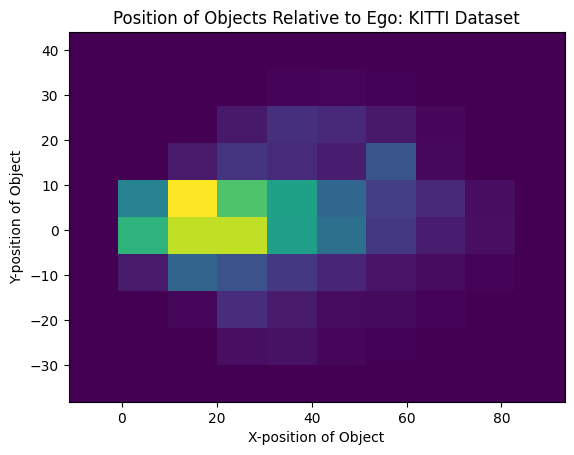

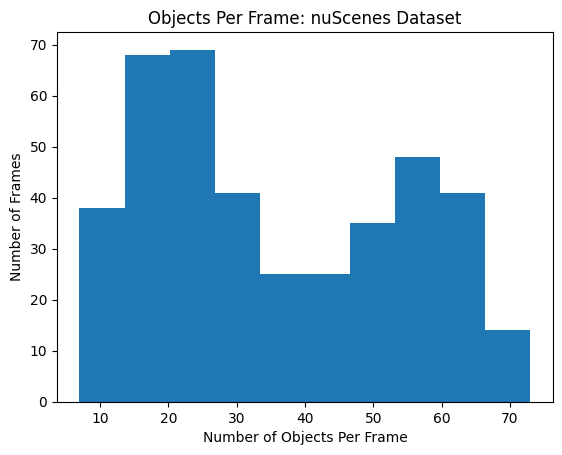

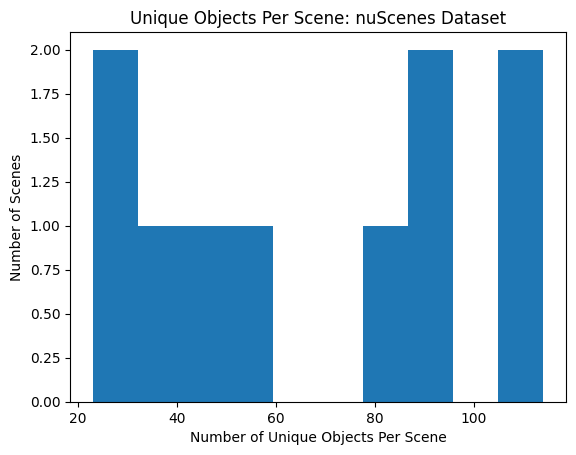

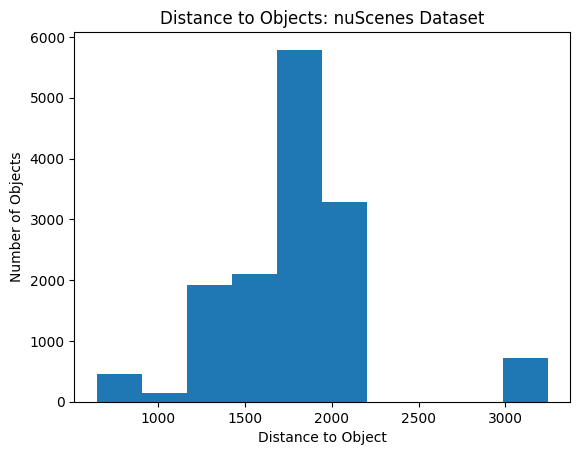

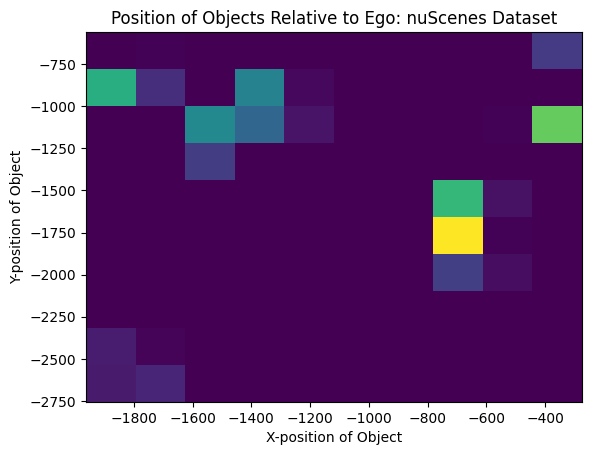

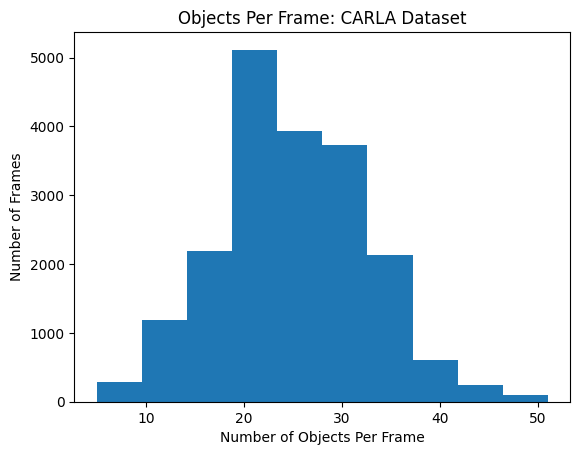

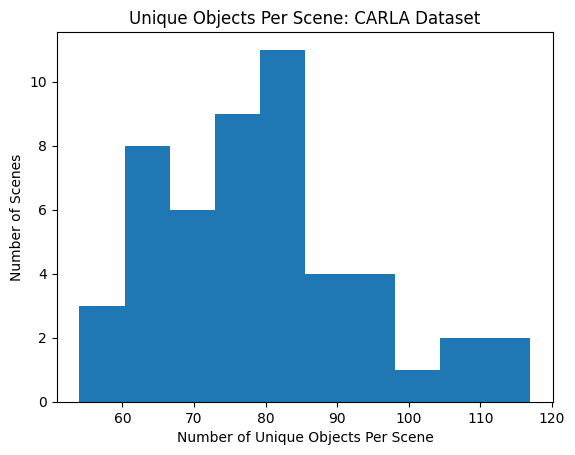

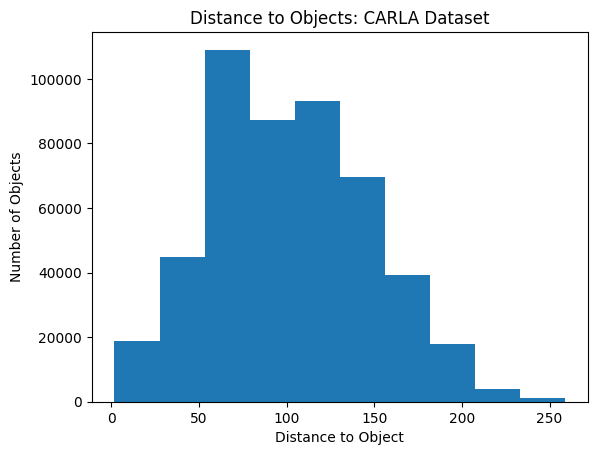

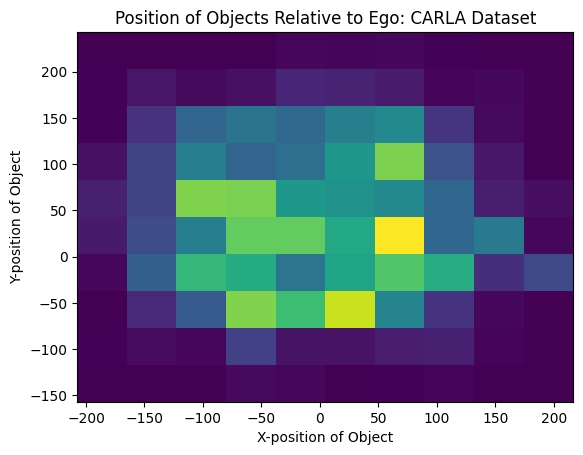

In [36]:
SMs = [KSM, NSM, CSM]

for SM in SMs:
    obj_all = [] # objects per frame
    obj_unq = [] # unqiue objects per scene
    obj_dist = [] # distance to each object in each frame of each scene
    obj_x = [] # x-pos of each object (relative to ego) in each frame of each scene 
    obj_y = [] # y-pos of each object (relative to ego) in each frame of each scene
    for i in range(len(SM.scenes)):
        # Deriving SceneDataset from SceneManager
        obj_frame_scene = []
        count_obj_unqui_curr_scene = 0
        obj_id_set = set()
        DM = SM.get_scene_dataset_by_index(scene_idx=i)
        if DM.frames is None:
            continue
        range_frames = range(len(DM.frames))
        if (SM == CSM):
            range_frames = range(4, len(DM.frames)-5)
        for frame_idx in range_frames:
            frame = DM.get_frames(sensor="main_camera")[frame_idx]
            objects = DM.get_objects(frame, sensor='main_lidar')
            obj_all.append(len(objects))
            ego = DM.get_ego(frame)
            for obj in objects:
                # check if obj is unique in scene
                if (obj.ID not in obj_id_set):
                    count_obj_unqui_curr_scene += 1
                obj_id_set.add(obj.ID)
    
                # x,y,z position of obj relative to ego
                x_pos = obj.position.x[0]-ego.position.x[0]
                y_pos = obj.position.x[1]-ego.position.x[1]
                z_pos = obj.position.x[2]-ego.position.x[2]
                # distance of obj to ego
                dist = math.sqrt(math.pow(x_pos, 2) + math.pow(y_pos, 2) + math.pow(z_pos, 2)* 1.0)
                
                obj_x.append(x_pos)
                obj_y.append(y_pos)
                obj_dist.append(dist)
                
        obj_unq.append(count_obj_unqui_curr_scene)   

    # plotting histograms
    title = ""
    if SM == KSM:
        title = "KITTI Dataset"
    elif SM == NSM: 
        title = "nuScenes Dataset"
    else:
        title = "CARLA Dataset"
        
    plt.hist(obj_all)
    plt.title("Objects Per Frame: " + title)
    plt.xlabel('Number of Objects Per Frame')
    plt.ylabel('Number of Frames')
    plt.show()
    
    plt.hist(obj_unq)
    plt.title("Unique Objects Per Scene: " + title)
    plt.xlabel('Number of Unique Objects Per Scene')
    plt.ylabel('Number of Scenes')
    plt.show()
    
    plt.hist(obj_dist)
    plt.title("Distance to Objects: " + title)
    plt.xlabel('Distance to Object')
    plt.ylabel('Number of Objects')
    plt.show()
    
    plt.hist2d(obj_x, obj_y)
    plt.title("Position of Objects Relative to Ego: " + title)
    plt.xlabel('X-position of Object')
    plt.ylabel('Y-position of Object')
    plt.show()
